# 02. 데이터셋 구축 및 탐색적 데이터 분석 (EDA)

## 학습 목표
1. **YOLO 형식** PCB 결함 데이터셋 구조를 이해한다.
2. 이미지·라벨 **정합성 검증** 파이프라인을 구축한다.
3. 클래스 분포, 조명·해상도·회전 **메타데이터**를 분석한다.
4. 바운딩 박스 시각화로 **라벨 품질**을 점검한다.

---

## 데이터셋 개요
- **출처**: PCB Defect Dataset (DeepPCB 기반, YOLO 포맷)
- **경로**: `data/pcb-defect-dataset/pcb-defect-dataset/`
- **분할**: train / val / test
- **클래스**: 6종 결함

In [1]:
from pathlib import Path
import re
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from collections import Counter

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

PROJECT_ROOT = Path("..").resolve()
DATA_ROOT = PROJECT_ROOT / "data" / "pcb-defect-dataset" / "pcb-defect-dataset"

with open(PROJECT_ROOT / "config" / "dataset.yaml", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

CLASS_NAMES = {int(k): v for k, v in cfg["names"].items()}
SPLITS = ["train", "val", "test"]

print(f"데이터 루트: {DATA_ROOT}")
print(f"존재 여부  : {DATA_ROOT.exists()}")
print(f"클래스     : {CLASS_NAMES}")

데이터 루트: C:\MyCursorLab\10_프로젝트\data\pcb-defect-dataset\pcb-defect-dataset
존재 여부  : True
클래스     : {0: 'mouse_bite', 1: 'spur', 2: 'missing_hole', 3: 'short', 4: 'open_circuit', 5: 'spurious_copper'}


## 1. 데이터셋 디렉터리 구조

```
pcb-defect-dataset/
├── data.yaml
├── train/
│   ├── images/   (*.jpg)
│   └── labels/   (*.txt, YOLO format)
├── val/
│   ├── images/
│   └── labels/
└── test/
    ├── images/
    └── labels/
```

**YOLO 라벨 형식**: `class_id cx cy w h` (모두 0~1 정규화)

In [2]:
def count_split(split: str) -> dict:
    img_dir = DATA_ROOT / split / "images"
    lbl_dir = DATA_ROOT / split / "labels"
    images = sorted(img_dir.glob("*.jpg"))
    labels = sorted(lbl_dir.glob("*.txt"))
    img_stems = {p.stem for p in images}
    lbl_stems = {p.stem for p in labels}
    return {
        "split": split,
        "images": len(images),
        "labels": len(labels),
        "matched": len(img_stems & lbl_stems),
        "img_only": len(img_stems - lbl_stems),
        "lbl_only": len(lbl_stems - img_stems),
    }

split_df = pd.DataFrame([count_split(s) for s in SPLITS])
split_df

,split,images,labels,matched,img_only,lbl_only
0,train,8534,8534,6370,2164,2164
1,val,1066,1066,802,264,264
2,test,1068,1068,829,239,239


In [3]:
# 파일명에서 메타데이터 파싱
# 예: rotation_270_light_09_short_02_1_600.jpg
#     l_light_01_missing_hole_08_3_600.jpg
#     light_01_missing_hole_08_3_256.jpg

FILENAME_RE = re.compile(
    r"^(?:(l)_)?(?:(rotation_\d+)_)?light_(\d+)_(.+?)_(\d+)_(\d+)_(256|600)$"
)

def parse_filename(stem: str) -> dict:
    m = FILENAME_RE.match(stem)
    if not m:
        return {"stem": stem, "parsed": False}
    flip_prefix, rotation, light, defect, board_id, variant, resolution = m.groups()
    return {
        "stem": stem,
        "parsed": True,
        "flip_prefix": flip_prefix or "none",
        "rotation": rotation or "none",
        "light": f"light_{light}",
        "defect_from_name": defect,
        "resolution": int(resolution),
    }

# train 메타데이터 샘플
sample_stems = [p.stem for p in sorted((DATA_ROOT / "train" / "images").glob("*.jpg"))[:5]]
pd.DataFrame([parse_filename(s) for s in sample_stems])

,stem,parsed,flip_prefix,rotation,light,defect_from_name,resolution
0,l_light_01_missing_hole_01_1_600,True,l,none,light_01,missing_hole,600
1,l_light_01_missing_hole_01_2_600,True,l,none,light_01,missing_hole,600
2,l_light_01_missing_hole_02_1_600,True,l,none,light_01,missing_hole,600
3,l_light_01_missing_hole_02_2_600,True,l,none,light_01,missing_hole,600
4,l_light_01_missing_hole_02_3_600,True,l,none,light_01,missing_hole,600


In [4]:
def load_yolo_labels(label_path: Path) -> list[tuple[int, float, float, float, float]]:
    boxes = []
    if not label_path.exists():
        return boxes
    for line in label_path.read_text(encoding="utf-8").strip().splitlines():
        if not line.strip():
            continue
        cls, cx, cy, w, h = map(float, line.split())
        boxes.append((int(cls), cx, cy, w, h))
    return boxes


def build_annotation_dataframe(splits=None) -> pd.DataFrame:
    splits = splits or SPLITS
    rows = []
    skipped_missing_image = 0

    for split in splits:
        lbl_dir = DATA_ROOT / split / "labels"
        img_stems = {p.stem for p in (DATA_ROOT / split / "images").glob("*.jpg")}

        for lbl_path in lbl_dir.glob("*.txt"):
            # 라벨-이미지 불일치 샘플은 EDA 테이블에서 제외
            if lbl_path.stem not in img_stems:
                skipped_missing_image += 1
                continue

            meta = parse_filename(lbl_path.stem)
            boxes = load_yolo_labels(lbl_path)
            for cls, cx, cy, w, h in boxes:
                rows.append({
                    "split": split,
                    "stem": lbl_path.stem,
                    "class_id": cls,
                    "class_name": CLASS_NAMES.get(cls, "unknown"),
                    "cx": cx, "cy": cy, "w": w, "h": h,
                    "bbox_area": w * h,
                    **{k: meta.get(k) for k in ["rotation", "light", "resolution", "defect_from_name"]},
                })
            if not boxes:
                rows.append({
                    "split": split,
                    "stem": lbl_path.stem,
                    "class_id": -1,
                    "class_name": "no_label",
                    "cx": np.nan,
                    "cy": np.nan,
                    "w": np.nan,
                    "h": np.nan,
                    "bbox_area": np.nan,
                    **{k: meta.get(k) for k in ["rotation", "light", "resolution", "defect_from_name"]},
                })

    df = pd.DataFrame(rows)
    print(f"이미지 없는 라벨 스킵 수: {skipped_missing_image}")
    return df

print("어노테이션 로딩 중... (수 분 소요될 수 있음)")
ann_df = build_annotation_dataframe()
print(f"총 bbox 수: {len(ann_df):,}")
ann_df.head()

어노테이션 로딩 중... (수 분 소요될 수 있음)
이미지 없는 라벨 스킵 수: 2667
총 bbox 수: 16,248


,split,stem,class_id,class_name,cx,cy,w,h,bbox_area,rotation,light,resolution,defect_from_name
0,train,l_light_01_missing_hole_01_1_600,2,missing_hole,0.4350,0.7008,0.0700,0.0550,0.003850,none,light_01,600,missing_hole
1,train,l_light_01_missing_hole_01_2_600,2,missing_hole,0.6367,0.0508,0.0667,0.0617,0.004115,none,light_01,600,missing_hole
2,train,l_light_01_missing_hole_01_2_600,2,missing_hole,0.7575,0.5333,0.0717,0.0600,0.004302,none,light_01,600,missing_hole
3,train,l_light_01_missing_hole_02_1_600,2,missing_hole,0.5633,0.2783,0.0667,0.0667,0.004449,none,light_01,600,missing_hole
4,train,l_light_01_missing_hole_02_1_600,2,missing_hole,0.3208,0.8733,0.0383,0.0567,0.002172,none,light_01,600,missing_hole


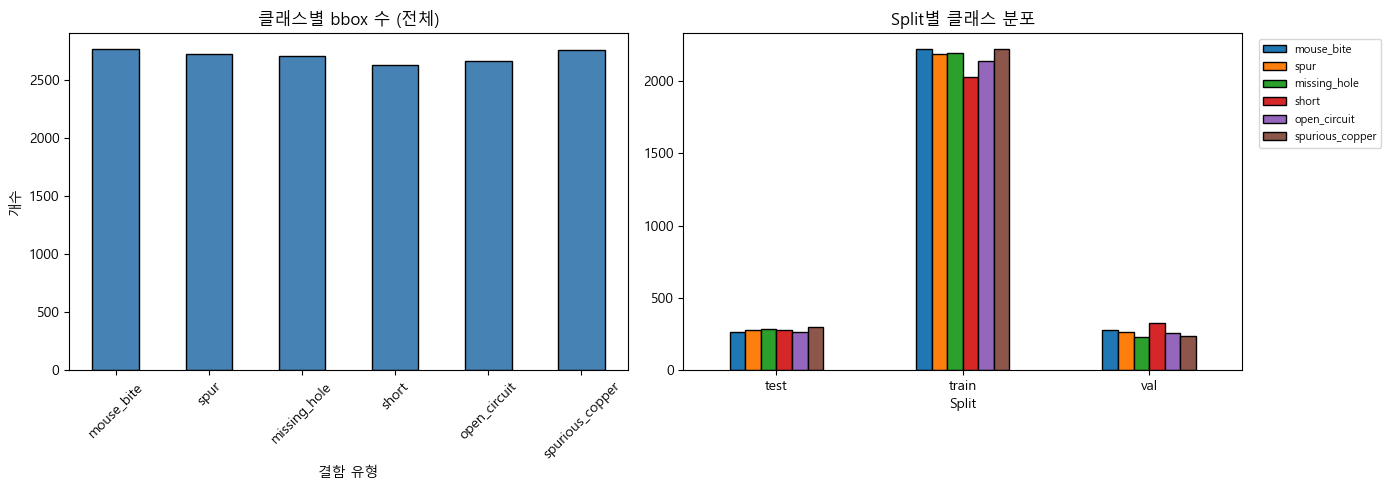

클래스 불균형 비율 (max/min): 1.05x


In [5]:
# 클래스별 분포
class_counts = (
    ann_df[ann_df["class_id"] >= 0]
    .groupby("class_name").size()
    .reindex(CLASS_NAMES.values(), fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("클래스별 bbox 수 (전체)")
axes[0].set_xlabel("결함 유형")
axes[0].set_ylabel("개수")
axes[0].tick_params(axis="x", rotation=45)

split_class = (
    ann_df[ann_df["class_id"] >= 0]
    .groupby(["split", "class_name"]).size()
    .unstack(fill_value=0)
    .reindex(columns=CLASS_NAMES.values(), fill_value=0)
)
split_class.plot(kind="bar", ax=axes[1], edgecolor="black")
axes[1].set_title("Split별 클래스 분포")
axes[1].set_xlabel("Split")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

# 불균형 비율
ratio = class_counts.max() / class_counts.min()
print(f"클래스 불균형 비율 (max/min): {ratio:.2f}x")

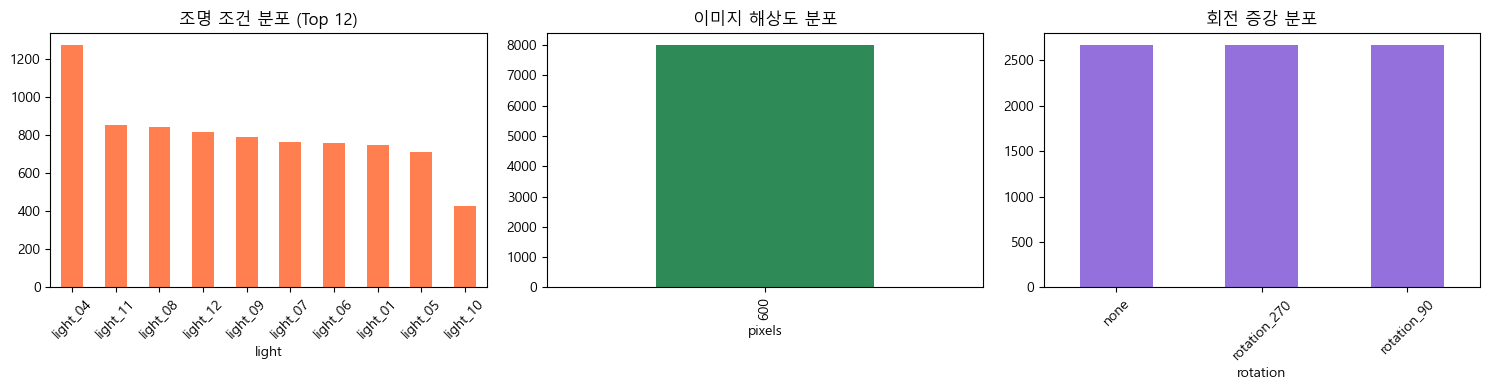

In [6]:
# 메타데이터 분포: 조명, 해상도, 회전
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

img_meta = ann_df.drop_duplicates("stem")
img_meta["light"].value_counts().head(12).plot(kind="bar", ax=axes[0], color="coral")
axes[0].set_title("조명 조건 분포 (Top 12)")
axes[0].tick_params(axis="x", rotation=45)

img_meta["resolution"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="seagreen")
axes[1].set_title("이미지 해상도 분포")
axes[1].set_xlabel("pixels")

img_meta["rotation"].value_counts().plot(kind="bar", ax=axes[2], color="mediumpurple")
axes[2].set_title("회전 증강 분포")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

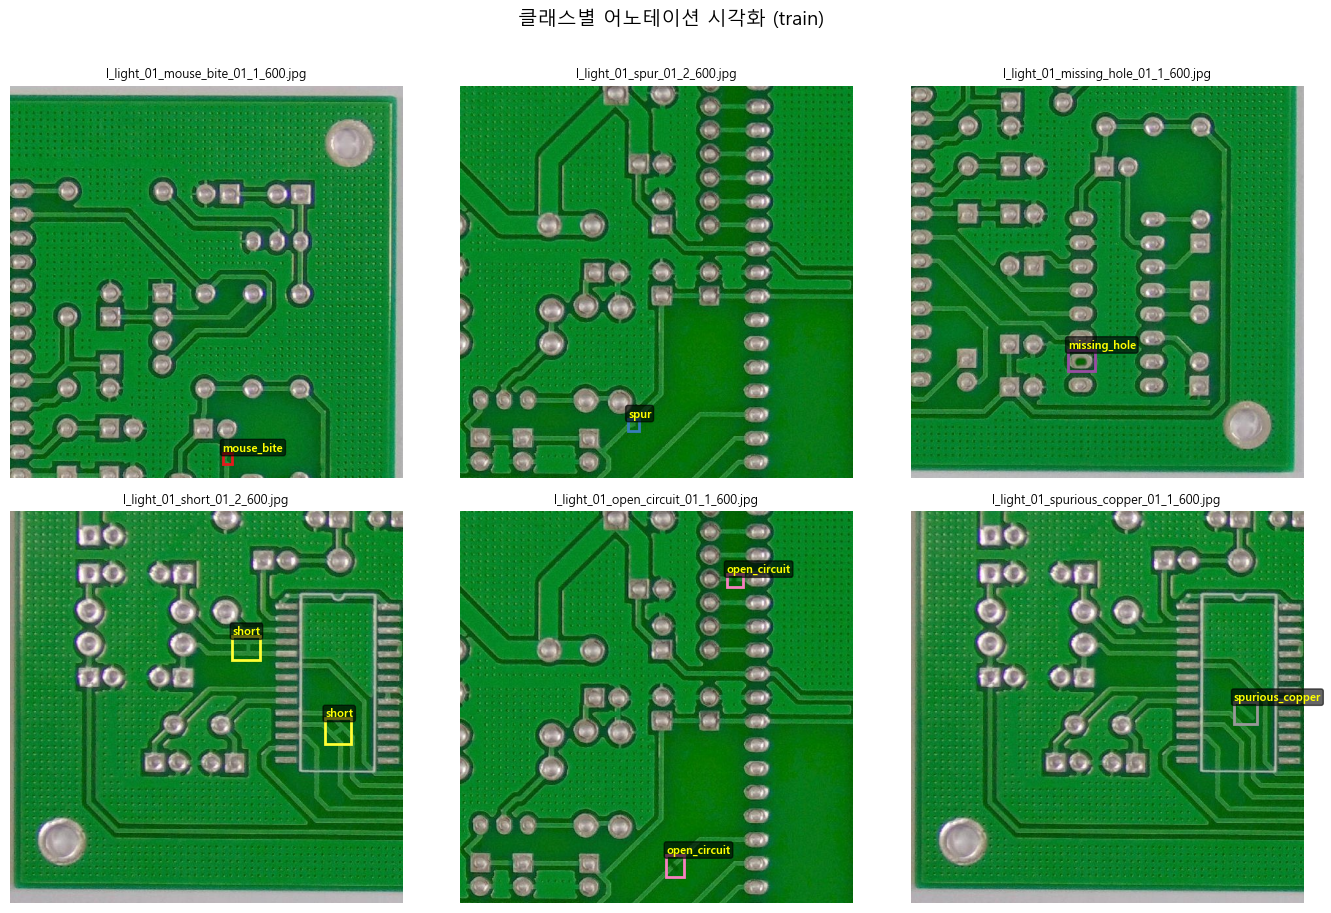

In [7]:
COLORS = plt.cm.Set1(np.linspace(0, 1, len(CLASS_NAMES)))


def resolve_image_path(split: str, stem: str) -> Path | None:
    """stem에 대응하는 이미지 파일을 안전하게 찾는다."""
    img_dir = DATA_ROOT / split / "images"
    candidates = [
        img_dir / f"{stem}.jpg",
        img_dir / f"l_{stem}.jpg",
        img_dir / f"rotation_90_{stem}.jpg",
        img_dir / f"rotation_270_{stem}.jpg",
    ]
    for p in candidates:
        if p.exists():
            return p
    return None


def draw_yolo_boxes(image_path: Path, label_path: Path, ax=None):
    img = Image.open(image_path).convert("RGB")
    w_img, h_img = img.size
    boxes = load_yolo_labels(label_path)

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(img)
    ax.set_axis_off()

    for cls, cx, cy, bw, bh in boxes:
        x = (cx - bw / 2) * w_img
        y = (cy - bh / 2) * h_img
        rect = patches.Rectangle(
            (x, y), bw * w_img, bh * h_img,
            linewidth=2, edgecolor=COLORS[cls % len(COLORS)], facecolor="none",
        )
        ax.add_patch(rect)
        ax.text(x, y - 3, CLASS_NAMES.get(cls, str(cls)),
                color="yellow", fontsize=8, weight="bold",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="black", alpha=0.6))
    ax.set_title(image_path.name, fontsize=9)
    return ax


# 클래스별 샘플 1장씩 시각화
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for cls_id, cls_name in CLASS_NAMES.items():
    candidates = ann_df[(ann_df["class_id"] == cls_id) & (ann_df["split"] == "train")]

    img_path, lbl_path = None, None
    for _, row in candidates.iterrows():
        candidate_img = resolve_image_path("train", row["stem"])
        candidate_lbl = DATA_ROOT / "train" / "labels" / f"{row['stem']}.txt"
        if candidate_img is not None and candidate_lbl.exists():
            img_path, lbl_path = candidate_img, candidate_lbl
            break

    if img_path is None:
        axes[cls_id].text(0.5, 0.5, f"{cls_name}\n샘플 이미지 없음", ha="center", va="center")
        axes[cls_id].set_axis_off()
        continue

    draw_yolo_boxes(img_path, lbl_path, ax=axes[cls_id])

plt.suptitle("클래스별 어노테이션 시각화 (train)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 2. 데이터 품질 검증 체크리스트

| 검증 항목 | 방법 | 기대 결과 |
|----------|------|----------|
| 이미지-라벨 1:1 매칭 | stem 교집합 | img_only = lbl_only = 0 |
| bbox 좌표 범위 | 0 ≤ cx,cy,w,h ≤ 1 | 위반 0건 |
| 빈 라벨 파일 | labels 내용 확인 | 결함 이미지는 비어있지 않음 |
| 클래스 ID 유효성 | 0~5 범위 | unknown 0건 |
| 파일명-라벨 클래스 | defect_from_name vs class_name | 대체로 일치 |

In [8]:
valid = ann_df[ann_df["class_id"] >= 0].copy()

# bbox 좌표 범위 검증
coord_cols = ["cx", "cy", "w", "h"]
out_of_range = valid[(valid[coord_cols] < 0).any(axis=1) | (valid[coord_cols] > 1).any(axis=1)]
invalid_class = valid[~valid["class_id"].isin(CLASS_NAMES.keys())]

print("=== 데이터 품질 리포트 ===")
print(f"bbox 좌표 범위 위반: {len(out_of_range)}건")
print(f"유효하지 않은 class_id: {len(invalid_class)}건")
print(f"bbox 면적 평균: {valid['bbox_area'].mean():.4f}")
print(f"bbox 면적 중앙값: {valid['bbox_area'].median():.4f}")

# 파일명 결함유형 vs 라벨 클래스 교차표 (샘플)
name_vs_label = (
    valid.drop_duplicates("stem")
    .groupby(["defect_from_name", "class_name"]).size()
    .unstack(fill_value=0)
)
print("\n파일명 결함유형 vs 라벨 클래스:")
display(name_vs_label)

=== 데이터 품질 리포트 ===
bbox 좌표 범위 위반: 0건
유효하지 않은 class_id: 0건
bbox 면적 평균: 0.0026
bbox 면적 중앙값: 0.0022

파일명 결함유형 vs 라벨 클래스:


class_name,missing_hole,mouse_bite,open_circuit,short,spur,spurious_copper
defect_from_name,,,,,,
missing_hole,1374,0,0,0,0,0
mouse_bite,0,1389,0,0,0,0
open_circuit,0,0,1305,0,0,0
short,0,0,0,1299,0,0
spur,0,0,0,0,1314,0
spurious_copper,0,0,0,0,0,1320


## 3. 📝 실습: 데이터셋 구축 워크시트

1. **분할 비율**을 계산하고, train/val/test 비율이 적절한지 토론하세요.
2. **클래스 불균형**이 모델에 미칠 영향과 대응 전략(가중치, 오버샘플링 등)을 작성하세요.
3. **조명 조건(light_XX)** 이 다양한 이유를 AOI 현장 관점에서 설명하세요.
4. 새 결함 유형이 추가된다면 **데이터셋 구축 절차** 5단계를 작성하세요.

---

## 다음 단계
→ **03_센서영상_문제정의_실습.ipynb**